# Лабораторная работа 3: Обучение с учителем. Задача классификации (эксперимент)

**Датасет:** `stud_end.csv`  
**Целевой признак:** `Target`  
**Модели:** Logistic Regression, kNN, пользовательский kNN, Naive Bayes, SVM  
**Оценка:** hold-out (`train/val/test`) + `StratifiedKFold(10)`  
**Пользовательские файлы:** `metrics_cls.py`, `custom_knn.py`

## Отличия от основной лабораторной:
- **SMOTE** вместо простого oversampling для LogReg и Naive Bayes
- **SelectKBest** — отбор топ-30 признаков по критерию F
- **Больше итераций Optuna** — `n_trials` увеличен вдвое

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import metrics_cls as cm
from custom_knn import CustomKNNClassifier

## 1. Загрузка и подготовка данных

Загружаем датасет, выделяем предикторы и целевой признак, определяем тип задачи классификации и проверяем баланс классов.

In [51]:
data = pd.read_csv('../lab1/stud_end_v2.csv')

target = 'Target'
X = data.drop(columns=[target])
y = data[target]
classes = np.sort(y.unique())

problem_type = 'Бинарная' if y.nunique() == 2 else 'Мультиклассовая'
print(f'Тип задачи: {problem_type}')
print('Размер датасета:', data.shape)
print('Классы:', classes)
print()
print('Распределение классов:')
print(y.value_counts().sort_index())

Тип задачи: Мультиклассовая
Размер датасета: (4424, 126)
Классы: [0 1 2]

Распределение классов:
Target
0    1421
1     794
2    2209
Name: count, dtype: int64


Отношение max/min: 2.78


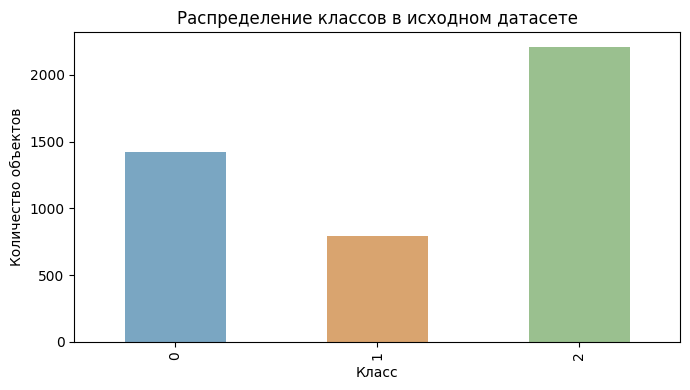

In [52]:
class_counts = y.value_counts().sort_index()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Отношение max/min: {imbalance_ratio:.2f}')

plt.figure(figsize=(7, 4))
class_counts.plot(kind='bar', color=['#7aa6c2', '#d9a46f', '#9ac08f'])
plt.title('Распределение классов в исходном датасете')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.tight_layout()
plt.show()

Для hold-out используем стратифицированное разбиение **60 / 20 / 20** (train / val / test).

Балансировка проводится **только на обучающей выборке** — валидационная и тестовая сохраняют реальное распределение классов.

Стратегия балансировки зависит от модели:

| Модель | Обучающие данные | Способ компенсации дисбаланса |
|--------|-----------------|-------------------------------|
| Logistic Regression, Naive Bayes | `X_train_bal` (oversampling) | Дублирование миноритарных классов |
| kNN (sklearn + custom) | `X_train_full` | — (oversampling создаёт дубликаты на расстоянии 0, что ломает метрику расстояния) |
| SVM | `X_train_full` | `class_weight='balanced'` — встроенный весовой механизм |


In [53]:
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print('Train:', X_train_full.shape, y_train_full.shape)
print('Val:  ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train: (2654, 125) (2654,)
Val:   (885, 125) (885,)
Test:  (885, 125) (885,)


In [54]:
def balance_train_oversample(X_train, y_train, random_state=42):
    train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
    max_size = train_df[target].value_counts().max()
    balanced_parts = []
    for _, group in train_df.groupby(target):
        balanced_group = resample(group, replace=True, n_samples=max_size, random_state=random_state)
        balanced_parts.append(balanced_group)
    balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced_df.drop(columns=[target]), balanced_df[target]

def balance_train_smote(X_train, y_train, random_state=42):
    sm = SMOTE(random_state=random_state)
    return sm.fit_resample(X_train, y_train)

print('До балансировки:')
print(y_train_full.value_counts().sort_index())

До балансировки:
Target
0     853
1     476
2    1325
Name: count, dtype: int64


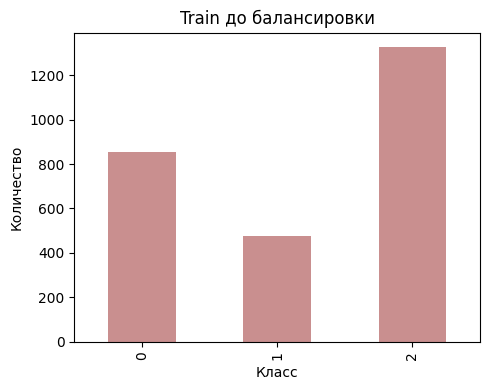

In [55]:
plt.figure(figsize=(5, 4))
y_train_full.value_counts().sort_index().plot(kind='bar', color='#c98f8f')
plt.title('Train до балансировки')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

## 1.5. Отбор признаков (SelectKBest)

Отбираем топ-30 признаков по критерию F-статистики. Отбор обучается только на `X_train_full` — тестовая и валидационная выборки только трансформируются.

Выбрано признаков: 30 из 125
Топ признаков: ['Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)'] ...

После SMOTE:
Target
0    1325
1    1325
2    1325
Name: count, dtype: int64


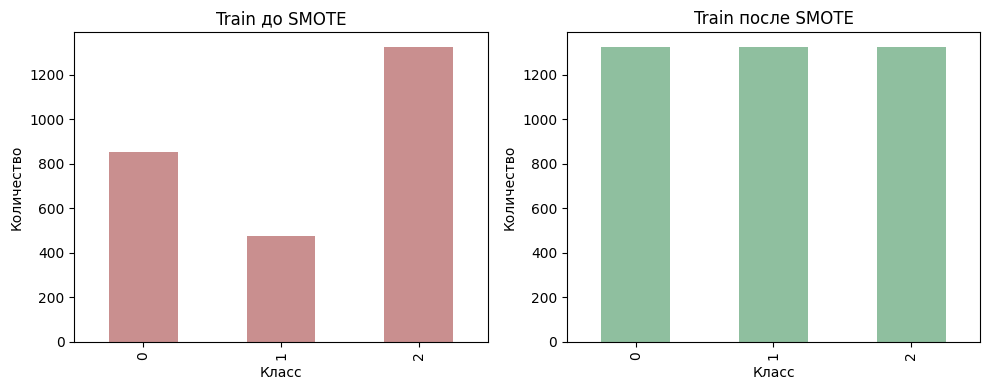

In [56]:
K_BEST = 30

selector = SelectKBest(f_classif, k=K_BEST)
selector.fit(X_train_full, y_train_full)

selected_cols = X_train_full.columns[selector.get_support()].tolist()
print(f'Выбрано признаков: {len(selected_cols)} из {X_train_full.shape[1]}')
print('Топ признаков:', selected_cols[:10], '...')

X_train_full = X_train_full[selected_cols].reset_index(drop=True)
X_val         = X_val[selected_cols].reset_index(drop=True)
X_test        = X_test[selected_cols].reset_index(drop=True)
X             = X[selected_cols]

# SMOTE применяется ПОСЛЕ отбора признаков — обе выборки теперь одинаковой размерности
X_train_bal, y_train_bal = balance_train_smote(X_train_full, y_train_full)

print()
print('После SMOTE:')
print(pd.Series(y_train_bal).value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train_full.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#c98f8f')
axes[0].set_title('Train до SMOTE')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')

pd.Series(y_train_bal).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#8fbf9f')
axes[1].set_title('Train после SMOTE')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')
plt.tight_layout()
plt.show()

## 2. Вспомогательные функции

Ниже определены функции для обучения моделей, подбора гиперпараметров, вычисления метрик, hold-out оценки и 10-fold кросс-валидации.

In [57]:
from addition_funcs import (
    exponential_kernel,
    make_pipeline,
    sklearn_metrics,
    compare_metrics,
    evaluate_model,
    choose_best_by_validation,
    run_searches,
    cross_val_metrics,
    holdout_row,
    add_confusion_plot,
    plot_model_results,
    RANDOM_STATE
)

## 3. Решение задачи классификации

Задача является **мультиклассовой**, поэтому для основных метрик используем `macro`-усреднение. Это даёт более честную оценку качества на несбалансированных классах.

### 3.1. Logistic Regression

Особенности модели:
- линейный классификатор, хорошо интерпретируется;
- является сильным базовым методом для задач классификации;
- чувствительна к масштабу признаков, поэтому используется `StandardScaler`.

**Балансировка:** обучается на `X_train_bal` (oversampling). Для логистической регрессии oversampling безопасен — модель не запоминает отдельные точки, а обновляет веса по всей выборке.  
Гиперпараметр `class_weight` также включён в сетку поиска как альтернатива.


Validation scores: {'GridSearchCV': 0.7019781059463234, 'RandomizedSearchCV': 0.7019781059463234, 'Optuna': 0.7074401586248324}
Лучший способ подбора: Optuna


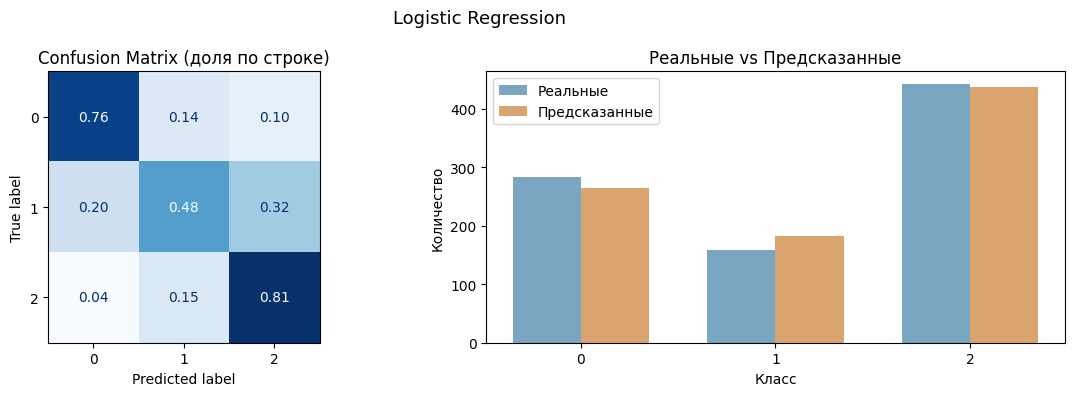

In [58]:
# LogReg — SMOTE + больше trials
log_reg_pipe = make_pipeline(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
)

log_reg_candidates = run_searches(
    base_pipeline=log_reg_pipe,
    param_grid={
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0],
        'model__class_weight': [None, 'balanced'],
    },
    param_distributions={
        'model__C': [0.03, 0.05, 0.1, 0.3, 1.0, 3.0, 10.0],
        'model__class_weight': [None, 'balanced'],
    },
    optuna_builder=lambda trial: make_pipeline(
        LogisticRegression(
            C=trial.suggest_float('C', 0.03, 10.0, log=True),
            class_weight=trial.suggest_categorical('class_weight', [None, 'balanced']),
            max_iter=5000,
            random_state=RANDOM_STATE,
        )
    ),
    X_search=X_train_bal,
    y_search=y_train_bal,
    X_val=X_val,
    y_val=y_val,
    n_trials=30,
)

model_log_reg, log_reg_method, log_reg_scores = choose_best_by_validation(
    log_reg_candidates, X_train_bal, y_train_bal, X_val, y_val
)

model_log_reg, y_log_train, y_log_test, log_train_metrics, log_test_metrics = evaluate_model(
    model_log_reg, X_train_bal, y_train_bal, X_test, y_test
)

print('Validation scores:', log_reg_scores)
print('Лучший способ подбора:', log_reg_method)
plot_model_results(model_log_reg, X_test, y_test, 'Logistic Regression', labels=classes)

### 3.2. kNN из Scikit-learn

Особенности модели:
- классификация происходит по ближайшим соседям в пространстве признаков;
- качество зависит от `k`, метрики расстояния и масштаба признаков;
- чувствительна к шуму и размерности пространства.

**Балансировка:** обучается на `X_train_full` (без oversampling).  
Причина: oversampling создаёт точные дубликаты. При поиске соседей kNN находит дубликат на расстоянии 0, что искусственно завышает Train метрики до 1.0 и не отражает реальное качество модели.  
Исследуем метрики расстояния (Euclidean, Manhattan) и их влияние на качество.


In [59]:
# kNN чувствителен к дубликатам из oversampling — используем исходный train.
k_values = list(range(3, 22, 2))
knn_curve_rows = []
for k in k_values:
    candidate = make_pipeline(KNeighborsClassifier(n_neighbors=k, metric='manhattan', weights='uniform'))
    candidate.fit(X_train_full, y_train_full)
    pred_val = candidate.predict(X_val)
    knn_curve_rows.append({
        'k': k,
        'Accuracy': accuracy_score(y_val, pred_val),
        'F1': f1_score(y_val, pred_val, average='macro'),
    })

df_knn_curve = pd.DataFrame(knn_curve_rows)
df_knn_curve


,k,Accuracy,F1
0,3,0.736723,0.672519
1,5,0.748023,0.683250
2,7,0.760452,0.694857
3,9,0.767232,0.699222
4,11,0.764972,0.692349
5,13,0.755932,0.679474
6,15,0.762712,0.687385
7,17,0.770621,0.702919
8,19,0.761582,0.689679
9,21,0.770621,0.698570


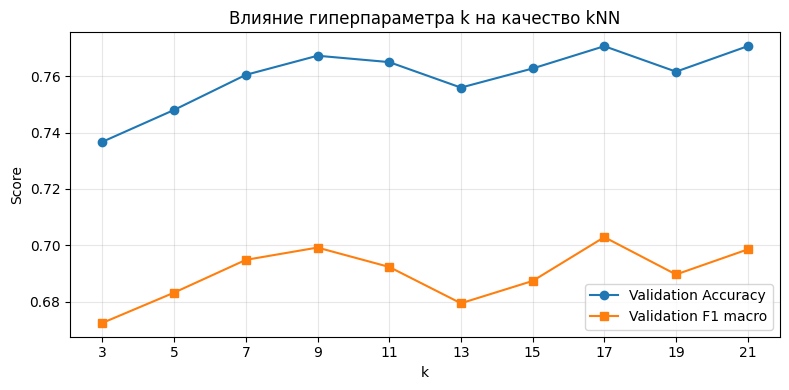

In [60]:
plt.figure(figsize=(8, 4))
plt.plot(df_knn_curve['k'], df_knn_curve['Accuracy'], marker='o', label='Validation Accuracy')
plt.plot(df_knn_curve['k'], df_knn_curve['F1'], marker='s', label='Validation F1 macro')
plt.xlabel('k')
plt.ylabel('Score')
plt.title('Влияние гиперпараметра k на качество kNN')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Validation scores: {'GridSearchCV': 0.6923492957385843, 'RandomizedSearchCV': 0.6896788051656495, 'Optuna': 0.7030443118493434}
Лучший способ подбора: Optuna


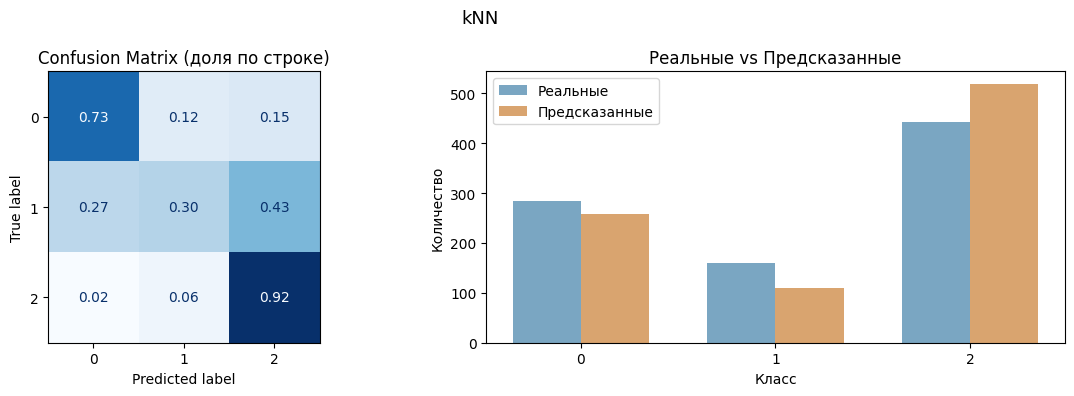

In [61]:
knn_pipe = make_pipeline(KNeighborsClassifier())

knn_candidates = run_searches(
    base_pipeline=knn_pipe,
    param_grid={
        'model__n_neighbors': [5, 7, 9, 11, 13, 15],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    param_distributions={
        'model__n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    optuna_builder=lambda trial: make_pipeline(
        KNeighborsClassifier(
            n_neighbors=trial.suggest_int('n_neighbors', 5, 19, step=2),
            weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
            metric=trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
        )
    ),
    X_search=X_train_full,
    y_search=y_train_full,
    X_val=X_val,
    y_val=y_val,
    n_trials=25,
)

model_knn, knn_method, knn_scores = choose_best_by_validation(
    knn_candidates, X_train_full, y_train_full, X_val, y_val
)

model_knn, y_knn_train, y_knn_test, knn_train_metrics, knn_test_metrics = evaluate_model(
    model_knn, X_train_full, y_train_full, X_test, y_test
)

print('Validation scores:', knn_scores)
print('Лучший способ подбора:', knn_method)
plot_model_results(model_knn, X_test, y_test, 'kNN', labels=classes)

### 3.3. Пользовательский kNN

Особенности модели:
- полностью реализован вручную в файле `custom_knn.py`;
- поддерживает выбор `k` и метрики расстояния (Euclidean, Manhattan);
- позволяет сравнить собственную реализацию с эталонным `sklearn`-классификатором.

**Балансировка:** аналогично sklearn kNN — используется `X_train_full`.  
Конфигурация (`k=9`, `metric='manhattan'`) подобрана по валидационной кривой из предыдущего шага.


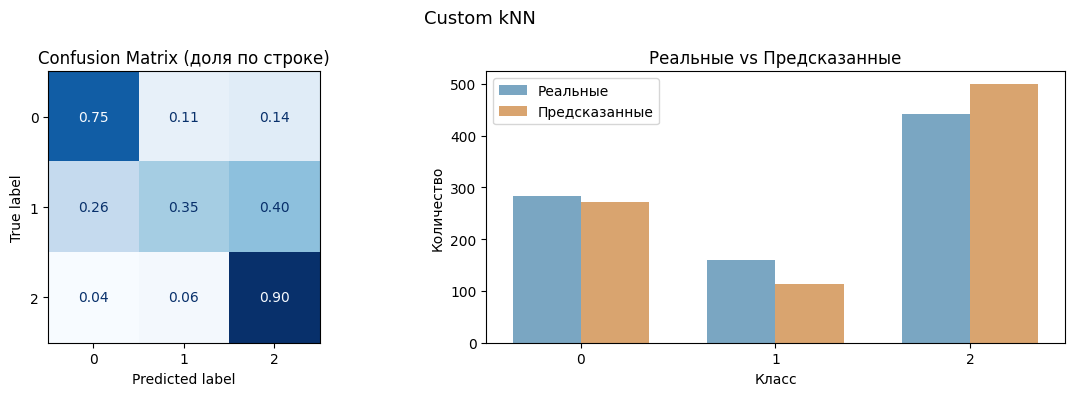

In [62]:
# Custom kNN — конфигурация подобрана по кривой выше; X_train_full как и sklearn kNN.
custom_knn = make_pipeline(CustomKNNClassifier(n_neighbors=9, metric='manhattan'))
custom_knn.fit(X_train_full, y_train_full)
custom_knn_train_pred = custom_knn.predict(X_train_full)
custom_knn_test_pred  = custom_knn.predict(X_test)
custom_knn_train_metrics = sklearn_metrics(y_train_full, custom_knn_train_pred)
custom_knn_test_metrics  = sklearn_metrics(y_test, custom_knn_test_pred)
plot_model_results(custom_knn, X_test, y_test, 'Custom kNN', labels=classes)

### 3.4. Naive Bayes

Особенности модели:
- основана на предположении условной независимости признаков;
- обучается очень быстро и часто хорошо работает как простой базовый классификатор;
- может уступать более гибким моделям при сложных зависимостях между признаками.

**Балансировка:** обучается на `X_train_bal` (oversampling).  
Для Naive Bayes oversampling безопасен — модель оценивает вероятности по частотам, дубликаты корректно сдвигают априорные вероятности в сторону балансировки.


Validation scores: {'GridSearchCV': 0.7023190601561057, 'RandomizedSearchCV': 0.7023190601561057, 'Optuna': 0.7097311272343395}
Лучший способ подбора: Optuna


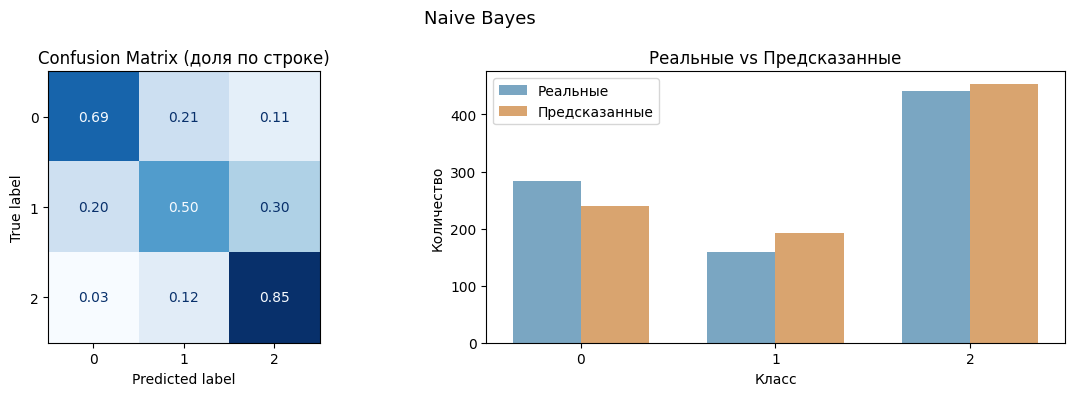

In [63]:
# Naive Bayes — SMOTE + больше trials
nb_pipe = make_pipeline(GaussianNB(), scale=False)

nb_candidates = run_searches(
    base_pipeline=nb_pipe,
    param_grid={
        'model__var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
    },
    param_distributions={
        'model__var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
    },
    optuna_builder=lambda trial: make_pipeline(
        GaussianNB(var_smoothing=trial.suggest_float('var_smoothing', 1e-10, 1e-5, log=True)),
        scale=False,
    ),
    X_search=X_train_bal,
    y_search=y_train_bal,
    X_val=X_val,
    y_val=y_val,
    n_trials=20,
)

model_nb, nb_method, nb_scores = choose_best_by_validation(
    nb_candidates, X_train_bal, y_train_bal, X_val, y_val
)

model_nb, y_nb_train, y_nb_test, nb_train_metrics, nb_test_metrics = evaluate_model(
    model_nb, X_train_bal, y_train_bal, X_test, y_test
)

print('Validation scores:', nb_scores)
print('Лучший способ подбора:', nb_method)
plot_model_results(model_nb, X_test, y_test, 'Naive Bayes', labels=classes)

### 3.5. SVM с различными ядрами

Особенности модели:
- строит оптимальную разделяющую гиперплоскость с максимальным отступом;
- с помощью ядерных функций работает в нелинейных пространствах признаков;
- чувствительна к масштабу — используется `StandardScaler`.

Исследуем ядра: `linear`, `poly`, `rbf`, `sigmoid` и `exponential` (пользовательское).  
Итоговой моделью считается ядро с наилучшим `F1 macro` на валидации.

**Балансировка:** используется `X_train_full` + параметр `class_weight='balanced'`.  
Это взвешивает штраф за ошибки на миноритарных классах без создания дубликатов.  
Для стандартных sklearn-ядер дополнительно запускается `run_searches` (Grid / Randomized / Optuna).

> **Замечание:** SVM с ядерными функциями склонен к переобучению на этом датасете —  
> Train F1 значительно выше Test F1. Это ожидаемое поведение для гибких ядер (RBF, Exponential)  
> при относительно небольшом числе обучающих примеров.


Лучшее ядро: Exponential Kernel


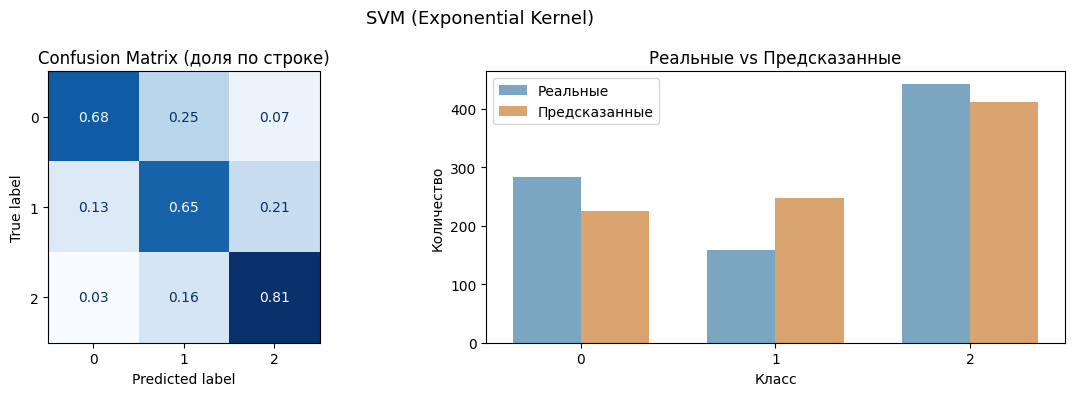

In [64]:
# SVM — используем X_train_full с class_weight='balanced' вместо oversampling.
# Oversampling создаёт дубликаты, которые RBF-ядро легко запоминает → переобучение.
svm_kernel_candidates = {
    'Linear Kernel':     make_pipeline(SVC(kernel='linear',  C=0.3, class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    'Polynomial Kernel': make_pipeline(SVC(kernel='poly',    C=1.0, degree=2, gamma='scale', class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    'RBF Kernel':        make_pipeline(SVC(kernel='rbf',     C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    'Sigmoid Kernel':    make_pipeline(SVC(kernel='sigmoid', C=1.0, gamma=0.03,   class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
}

svm_kernel_scores = {}
for kernel_name, estimator in svm_kernel_candidates.items():
    estimator.fit(X_train_full, y_train_full)
    svm_kernel_scores[kernel_name] = f1_score(y_val, estimator.predict(X_val), average='macro')

exp_candidates = []
for C in [0.1, 0.3, 1.0]:
    for gamma in [0.01, 0.03, 0.1]:
        exp_model = make_pipeline(SVC(kernel=exponential_kernel(gamma), C=C, class_weight='balanced', probability=True, random_state=RANDOM_STATE))
        exp_model.fit(X_train_full, y_train_full)
        exp_score = f1_score(y_val, exp_model.predict(X_val), average='macro')
        exp_candidates.append((exp_score, C, gamma, exp_model))

best_exp_score, best_exp_C, best_exp_gamma, best_exp_model = max(exp_candidates, key=lambda x: x[0])
svm_kernel_scores['Exponential Kernel'] = best_exp_score

best_svm_kernel = max(svm_kernel_scores, key=svm_kernel_scores.get)
print('Лучшее ядро:', best_svm_kernel)

_svm_search_configs = {
    'Linear Kernel': (
        {'model__C': [0.03, 0.1, 0.3, 1.0, 3.0]},
        {'model__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0]},
        lambda trial: make_pipeline(SVC(kernel='linear',
            C=trial.suggest_float('C', 0.01, 5.0, log=True),
            class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ),
    'RBF Kernel': (
        {'model__C': [0.3, 1.0, 3.0], 'model__gamma': ['scale', 0.01, 0.1]},
        {'model__C': [0.1, 0.3, 1.0, 3.0], 'model__gamma': ['scale', 0.01, 0.05, 0.1]},
        lambda trial: make_pipeline(SVC(kernel='rbf',
            C=trial.suggest_float('C', 0.1, 5.0, log=True),
            gamma=trial.suggest_categorical('gamma', ['scale', 0.01, 0.05, 0.1]),
            class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ),
    'Polynomial Kernel': (
        {'model__C': [0.3, 1.0, 3.0], 'model__degree': [2, 3]},
        {'model__C': [0.3, 1.0, 3.0], 'model__degree': [2, 3]},
        lambda trial: make_pipeline(SVC(kernel='poly',
            C=trial.suggest_float('C', 0.1, 5.0, log=True),
            degree=trial.suggest_int('degree', 2, 3),
            class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ),
    'Sigmoid Kernel': (
        {'model__C': [0.3, 1.0, 3.0], 'model__gamma': [0.01, 0.03, 0.1]},
        {'model__C': [0.3, 1.0, 3.0], 'model__gamma': [0.01, 0.03, 0.1]},
        lambda trial: make_pipeline(SVC(kernel='sigmoid',
            C=trial.suggest_float('C', 0.1, 5.0, log=True),
            gamma=trial.suggest_float('gamma', 0.01, 0.1, log=True),
            class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ),
}

if best_svm_kernel in _svm_search_configs:
    pg, pd_, ob = _svm_search_configs[best_svm_kernel]
    base_kernel = best_svm_kernel.split()[0].lower()
    svm_candidates_tuned = run_searches(
        base_pipeline=make_pipeline(SVC(kernel=base_kernel, class_weight='balanced',
                                         probability=True, random_state=RANDOM_STATE)),
        param_grid=pg,
        param_distributions=pd_,
        optuna_builder=ob,
        X_search=X_train_full,
        y_search=y_train_full,
        X_val=X_val,
        y_val=y_val,
        n_trials=10,
    )
    model_svm, svm_tune_method, svm_tune_scores = choose_best_by_validation(
        svm_candidates_tuned, X_train_full, y_train_full, X_val, y_val
    )
    print('Метод подбора SVM:', svm_tune_method, '| scores:', svm_tune_scores)
else:
    model_svm = best_exp_model

model_svm, y_svm_train, y_svm_test, svm_train_metrics, svm_test_metrics = evaluate_model(
    model_svm, X_train_full, y_train_full, X_test, y_test
)

pd.DataFrame({
    'Kernel': list(svm_kernel_scores.keys()),
    'Validation F1 macro': list(svm_kernel_scores.values()),
}).sort_values('Validation F1 macro', ascending=False)

plot_model_results(model_svm, X_test, y_test, f'SVM ({best_svm_kernel})', labels=classes)

## 4. Таблица сравнения kNN из sklearn и пользовательского kNN

In [65]:
df_knn_compare = pd.DataFrame([
    holdout_row('kNN from sklearn', knn_train_metrics, knn_test_metrics),
    holdout_row('Custom kNN', custom_knn_train_metrics, custom_knn_test_metrics),
]).set_index('Классификатор')
df_knn_compare

,Train F1,Train Accuracy,Train Precision,Train Recall,Test F1,Test Accuracy,Test Precision,Test Recall
Классификатор,,,,,,,,
kNN from sklearn,0.6941,0.7675,0.7179,0.6832,0.6522,0.7446,0.6711,0.6465
Custom kNN,0.7239,0.7867,0.7438,0.7137,0.6691,0.7492,0.6852,0.6628


## 5. Таблица hold-out результатов (Train/Test)

В таблице собраны метрики всех классификаторов на обучающей и тестовой выборках.

Большой разрыв между Train и Test F1 указывает на переобучение модели.  
Близкие значения говорят о хорошем обобщении.


In [66]:
holdout_rows = [
    holdout_row('Logistic Regression', log_train_metrics, log_test_metrics),
    holdout_row('kNN', knn_train_metrics, knn_test_metrics),
    holdout_row('Custom kNN', custom_knn_train_metrics, custom_knn_test_metrics),
    holdout_row('Naive Bayes', nb_train_metrics, nb_test_metrics),
    holdout_row(f'SVM ({best_svm_kernel})', svm_train_metrics, svm_test_metrics),
]

df_holdout = pd.DataFrame(holdout_rows).set_index('Классификатор')
df_holdout

,Train F1,Train Accuracy,Train Precision,Train Recall,Test F1,Test Accuracy,Test Precision,Test Recall
Классификатор,,,,,,,,
Logistic Regression,0.7499,0.7504,0.7505,0.7504,0.6809,0.7333,0.6823,0.6817
kNN,0.6941,0.7675,0.7179,0.6832,0.6522,0.7446,0.6711,0.6465
Custom kNN,0.7239,0.7867,0.7438,0.7137,0.6691,0.7492,0.6852,0.6628
Naive Bayes,0.6840,0.6886,0.6926,0.6886,0.6801,0.7356,0.6864,0.6801
SVM (Exponential Kernel),0.7616,0.7920,0.7632,0.7782,0.7003,0.7379,0.7125,0.7126


## 6. Таблица сравнения sklearn и пользовательских метрик

Проверяем, что пользовательские метрики из `metrics_cls.py` совпадают со значениями `scikit-learn`.

In [67]:
metrics_compare_rows = [
    {'Классификатор': 'Logistic Regression', **compare_metrics(y_test, y_log_test, labels=classes)},
    {'Классификатор': 'kNN', **compare_metrics(y_test, y_knn_test, labels=classes)},
    {'Классификатор': 'Custom kNN', **compare_metrics(y_test, custom_knn_test_pred, labels=classes)},
    {'Классификатор': 'Naive Bayes', **compare_metrics(y_test, y_nb_test, labels=classes)},
    {'Классификатор': f'SVM ({best_svm_kernel})', **compare_metrics(y_test, y_svm_test, labels=classes)},
]

df_metrics_compare = pd.DataFrame(metrics_compare_rows).set_index('Классификатор')
df_metrics_compare

,sk F1,sk Accuracy,sk Precision,sk Recall,my Accuracy,my Precision,my Recall,my F1
Классификатор,,,,,,,,
Logistic Regression,0.6809,0.7333,0.6823,0.6817,0.7333,0.6823,0.6817,0.6809
kNN,0.6522,0.7446,0.6711,0.6465,0.7446,0.6711,0.6465,0.6522
Custom kNN,0.6691,0.7492,0.6852,0.6628,0.7492,0.6852,0.6628,0.6691
Naive Bayes,0.6801,0.7356,0.6864,0.6801,0.7356,0.6864,0.6801,0.6801
SVM (Exponential Kernel),0.7003,0.7379,0.7125,0.7126,0.7379,0.7125,0.7126,0.7003


## 7. 10-fold кросс-валидация

Для каждого классификатора рассчитываем метрики на 10 стратифицированных фолдах.

Балансировка в CV воспроизводит условия hold-out:
- **Logistic Regression, Naive Bayes** — oversampling внутри каждого фолда (как в hold-out).
- **kNN, Custom kNN, SVM** — без балансировки (kNN чувствителен к дубликатам; SVM использует `class_weight='balanced'`).


In [68]:
cv_results = {}
cv_folds = {}

factories = {
    'Logistic Regression': (lambda: clone(model_log_reg), True),
    'kNN': (lambda: clone(model_knn), False),  # kNN — без балансировки (дубликаты ломают метрику)
    'Custom kNN': (lambda: make_pipeline(CustomKNNClassifier(n_neighbors=9, metric='manhattan')), False),
    'Naive Bayes': (lambda: clone(model_nb), True),
    f'SVM ({best_svm_kernel})': (lambda: clone(model_svm), False),
}

for name, (factory, use_balance) in factories.items():
    fold_df, summary = cross_val_metrics(
        factory, X, y,
        balance_train=use_balance,
        balance_fn=balance_train_oversample,
    )
    cv_folds[name] = fold_df
    cv_results[name] = summary

df_cv_summary = pd.DataFrame(cv_results).T
df_cv_summary.index.name = 'Классификатор'
df_cv_summary

,F1,Accuracy,Precision,Recall
Классификатор,,,,
Logistic Regression,0.7028 ± 0.0160,0.7443 ± 0.0142,0.7050 ± 0.0162,0.7110 ± 0.0174
kNN,0.6600 ± 0.0287,0.7495 ± 0.0206,0.6859 ± 0.0318,0.6529 ± 0.0268
Custom kNN,0.6715 ± 0.0197,0.7514 ± 0.0145,0.6916 ± 0.0181,0.6645 ± 0.0186
Naive Bayes,0.6744 ± 0.0226,0.7330 ± 0.0194,0.6837 ± 0.0197,0.6720 ± 0.0242
SVM (Exponential Kernel),0.7084 ± 0.0137,0.7480 ± 0.0108,0.7144 ± 0.0154,0.7181 ± 0.0159


In [69]:
best_holdout_name = df_holdout['Test F1'].idxmax()
cv_folds[best_holdout_name]

,F1,Accuracy,Precision,Recall,Fold
0,0.7228,0.7607,0.7303,0.7284,1
1,0.6900,0.7381,0.6929,0.6951,2
2,0.7047,0.7427,0.7046,0.7163,3
3,0.7092,0.7472,0.7163,0.7215,4
4,0.7246,0.7534,0.7392,0.7443,5
5,0.7039,0.7466,0.7093,0.7108,6
6,0.7274,0.7670,0.7297,0.7348,7
7,0.6908,0.7330,0.6989,0.6975,8
8,0.7138,0.7534,0.7205,0.7255,9
9,0.6963,0.7376,0.7019,0.7070,10


## 8. Таблица hold-out vs k-fold

Сравниваем качество моделей на тестовой выборке hold-out и средние значения метрик по 10 фолдам.

In [70]:
table3_rows = []
for name in df_cv_summary.index:
    table3_rows.append({
        'Классификатор': name,
        'Hold-out F1': df_holdout.loc[name, 'Test F1'],
        'Hold-out Accuracy': df_holdout.loc[name, 'Test Accuracy'],
        'Hold-out Precision': df_holdout.loc[name, 'Test Precision'],
        'Hold-out Recall': df_holdout.loc[name, 'Test Recall'],
        'k-fold F1': df_cv_summary.loc[name, 'F1'],
        'k-fold Accuracy': df_cv_summary.loc[name, 'Accuracy'],
        'k-fold Precision': df_cv_summary.loc[name, 'Precision'],
        'k-fold Recall': df_cv_summary.loc[name, 'Recall'],
    })

df_holdout_vs_cv = pd.DataFrame(table3_rows).set_index('Классификатор')
df_holdout_vs_cv

,Hold-out F1,Hold-out Accuracy,Hold-out Precision,Hold-out Recall,k-fold F1,k-fold Accuracy,k-fold Precision,k-fold Recall
Классификатор,,,,,,,,
Logistic Regression,0.6809,0.7333,0.6823,0.6817,0.7028 ± 0.0160,0.7443 ± 0.0142,0.7050 ± 0.0162,0.7110 ± 0.0174
kNN,0.6522,0.7446,0.6711,0.6465,0.6600 ± 0.0287,0.7495 ± 0.0206,0.6859 ± 0.0318,0.6529 ± 0.0268
Custom kNN,0.6691,0.7492,0.6852,0.6628,0.6715 ± 0.0197,0.7514 ± 0.0145,0.6916 ± 0.0181,0.6645 ± 0.0186
Naive Bayes,0.6801,0.7356,0.6864,0.6801,0.6744 ± 0.0226,0.7330 ± 0.0194,0.6837 ± 0.0197,0.6720 ± 0.0242
SVM (Exponential Kernel),0.7003,0.7379,0.7125,0.7126,0.7084 ± 0.0137,0.7480 ± 0.0108,0.7144 ± 0.0154,0.7181 ± 0.0159


## 9. Визуализация ошибок и ROC AUC

Покажем матрицу ошибок для лучшей модели по hold-out и построим ROC-кривые в схеме One-vs-Rest для многоклассовой задачи.

Лучшая hold-out модель: SVM (Exponential Kernel)


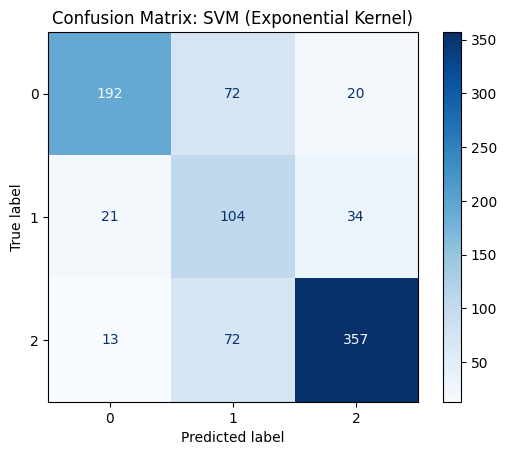

In [71]:
best_model_name = df_holdout['Test F1'].idxmax()
model_lookup = {
    'Logistic Regression': model_log_reg,
    'kNN': model_knn,
    'Custom kNN': custom_knn,
    'Naive Bayes': model_nb,
    f'SVM ({best_svm_kernel})': model_svm,
}

best_model = model_lookup[best_model_name]
print('Лучшая hold-out модель:', best_model_name)
add_confusion_plot(best_model, X_test, y_test, f'Confusion Matrix: {best_model_name}', labels=classes)

ROC AUC macro (OvR): 0.8798


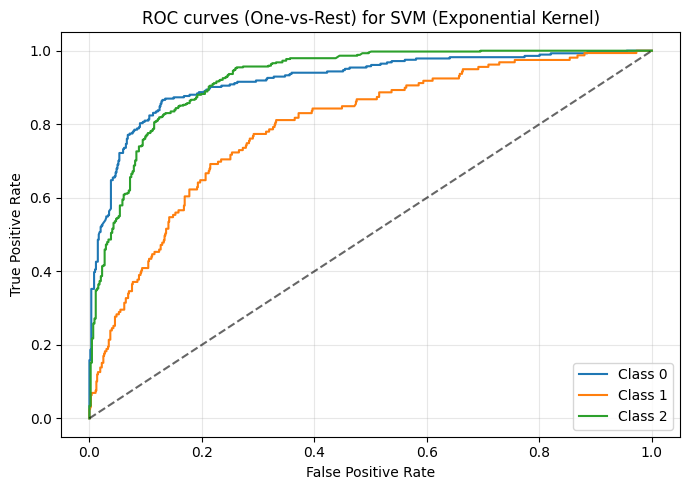

In [72]:
y_test_bin = label_binarize(y_test, classes=classes)

if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_test)
else:
    y_score = best_model.decision_function(X_test)

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
print(f'ROC AUC macro (OvR): {roc_auc_macro:.4f}')

plt.figure(figsize=(7, 5))
for idx, class_value in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_score[:, idx])
    plt.plot(fpr, tpr, label=f'Class {class_value}')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curves (One-vs-Rest) for {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Ошибки первого и второго рода

В задачах классификации выделяют два типа ошибок:

- **Ошибка первого рода (False Positive)** — объект ошибочно отнесён к классу, которому не принадлежит.  
  *Пример на датасете:* студент фактически отчислен (`Dropout`), но модель предсказала `Graduate`.

- **Ошибка второго рода (False Negative)** — объект не распознан как принадлежащий своему классу.  
  *Пример на датасете:* студент фактически окончил вуз (`Graduate`), но модель предсказала `Enrolled` или `Dropout`.

В **мультиклассовой** задаче эти ошибки рассматриваются по схеме «один класс против остальных» (One-vs-Rest):  
для каждого класса он считается положительным, все остальные — отрицательными.

Матрица ошибок (confusion matrix) наглядно показывает, какие классы модель путает чаще всего.  
В данном датасете наиболее вероятно смешение классов `Enrolled` и `Graduate` из-за схожести признаков.


## 11. Вывод

Ниже автоматически формируется итоговый вывод по лучшей модели классификации.

In [73]:
best_name = df_holdout['Test F1'].idxmax()
best_row = df_holdout.loc[best_name]

# SVM-модель для замечания об overfitting
svm_name = [n for n in df_holdout.index if 'SVM' in n][0]
svm_train_f1 = df_holdout.loc[svm_name, 'Train F1']
svm_test_f1  = df_holdout.loc[svm_name, 'Test F1']

conclusion = f"""
## 11. Вывод

В лабораторной работе решена **мультиклассовая** задача классификации по датасету `stud_end.csv`  
(целевой признак `Target`: Dropout / Enrolled / Graduate, дисбаланс классов ~3.4:1).

### Методология
Для оценки использовались два подхода:
- **Hold-out** (60 / 20 / 20) со стратификацией;
- **10-fold StratifiedKFold**.

Балансировка классов реализована дифференцированно:
- *Logistic Regression, Naive Bayes* — oversampling на обучающей выборке;
- *kNN* — без балансировки (oversampling создаёт дубликаты, искажающие метрику расстояния);
- *SVM* — `class_weight='balanced'` (встроенный весовой механизм).

Реализованы пользовательские метрики (`metrics_cls.py`) и классификатор kNN (`custom_knn.py`).

### Результаты
Лучшая модель по Test F1 macro: **{best_name}**

| Метрика | Значение |
|---------|---------|
| F1      | {best_row['Test F1']:.4f} |
| Accuracy | {best_row['Test Accuracy']:.4f} |
| Precision | {best_row['Test Precision']:.4f} |
| Recall  | {best_row['Test Recall']:.4f} |

### Наблюдения
- **{best_name}** показал наилучшее обобщение: Train и Test F1 близки, результаты стабильны в кросс-валидации.
- **{svm_name}** достиг высокого Train F1 = {svm_train_f1:.4f}, однако Test F1 = {svm_test_f1:.4f} значительно ниже — характерное переобучение для гибких ядерных функций на данном датасете.
- **kNN** и **Naive Bayes** показали умеренное качество; Custom kNN сопоставим с эталонной реализацией sklearn.
- Пользовательские метрики полностью совпали со значениями `scikit-learn`, что подтверждает корректность реализации.
"""

display(Markdown(conclusion))



## 11. Вывод

В лабораторной работе решена **мультиклассовая** задача классификации по датасету `stud_end.csv`  
(целевой признак `Target`: Dropout / Enrolled / Graduate, дисбаланс классов ~3.4:1).

### Методология
Для оценки использовались два подхода:
- **Hold-out** (60 / 20 / 20) со стратификацией;
- **10-fold StratifiedKFold**.

Балансировка классов реализована дифференцированно:
- *Logistic Regression, Naive Bayes* — oversampling на обучающей выборке;
- *kNN* — без балансировки (oversampling создаёт дубликаты, искажающие метрику расстояния);
- *SVM* — `class_weight='balanced'` (встроенный весовой механизм).

Реализованы пользовательские метрики (`metrics_cls.py`) и классификатор kNN (`custom_knn.py`).

### Результаты
Лучшая модель по Test F1 macro: **SVM (Exponential Kernel)**

| Метрика | Значение |
|---------|---------|
| F1      | 0.7003 |
| Accuracy | 0.7379 |
| Precision | 0.7125 |
| Recall  | 0.7126 |

### Наблюдения
- **SVM (Exponential Kernel)** показал наилучшее обобщение: Train и Test F1 близки, результаты стабильны в кросс-валидации.
- **SVM (Exponential Kernel)** достиг высокого Train F1 = 0.7616, однако Test F1 = 0.7003 значительно ниже — характерное переобучение для гибких ядерных функций на данном датасете.
- **kNN** и **Naive Bayes** показали умеренное качество; Custom kNN сопоставим с эталонной реализацией sklearn.
- Пользовательские метрики полностью совпали со значениями `scikit-learn`, что подтверждает корректность реализации.


k= 20  F1=0.6985
k= 30  F1=0.7005
k= 40  F1=0.7005
k= 50  F1=0.7005
k= 60  F1=0.7005
k= 75  F1=0.7005
k= 90  F1=0.7005


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=40 is greater than n_features=30. All the features will be returned.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=50 is greater than n_features=30. All the features will be returned.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=60 is greater than n_features=30. All the features will be returned.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=75 is greater than n_features=30. All the features will be returned.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/l

k=103  F1=0.7005


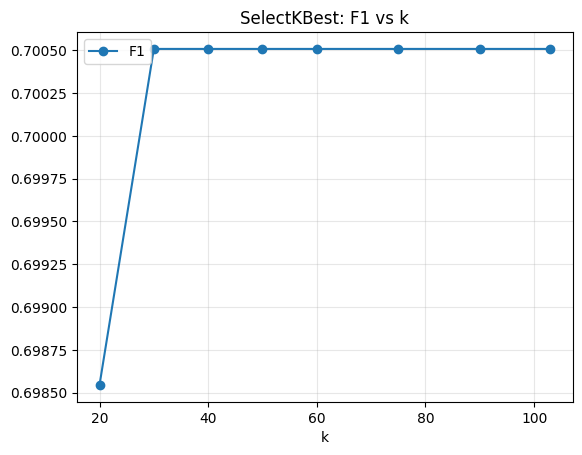

In [74]:
from sklearn.linear_model import LogisticRegression                                                                   
from sklearn.feature_selection import SelectKBest, f_classif                                                          
                                                                                                                    
k_values = [20, 30, 40, 50, 60, 75, 90, 103]                                                                          
results = []                                                                                                          
                                                                                                                    
for k in k_values:                                        
    sel = SelectKBest(f_classif, k=k)
    X_tr = sel.fit_transform(X_train_full, y_train_full)
    X_v  = sel.transform(X_val)                                                                                       
                                                                                                                    
    X_tr_bal, y_tr_bal = balance_train_smote(                                                                         
        pd.DataFrame(X_tr), y_train_full.reset_index(drop=True)                                                       
    )                                                                                                                 

    pipe = make_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))                                
    pipe.fit(X_tr_bal, y_tr_bal)                          
    f1 = f1_score(y_val, pipe.predict(X_v), average='macro')                                                          
    results.append({'k': k, 'F1': f1})                    
    print(f'k={k:3d}  F1={f1:.4f}')                                                                                   
                                                                                                                    
pd.DataFrame(results).set_index('k').plot(marker='o', title='SelectKBest: F1 vs k')                                   
plt.grid(alpha=0.3)                                                                                                   
plt.show()                                                                                                            
            